## observation data 

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import os
import xarray as xr
import xcdat as xc
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm as BM
import pandas as pd
import matplotlib as mpl
import matplotlib.ticker as mticker
import netCDF4
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
from scipy import stats

In [4]:
mpl.rcParams['font.family'] = 'Droid Sans'
mpl.rcParams['font.size'] = 12
# Edit axes parameters
mpl.rcParams['axes.linewidth'] = 1.5
# Tick properties
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['xtick.major.width'] = 1
mpl.rcParams['xtick.direction'] = 'out'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 3
mpl.rcParams['ytick.major.width'] = 1
mpl.rcParams['ytick.direction'] = 'out'

In [5]:
# plt.style.use('dark_background')

### Functions needed for the analysis

In [6]:
import matplotlib as m
from matplotlib.colors import BoundaryNorm as BM
import matplotlib.patches as mpatches

def plot_background(ax):
    ax.add_feature(cfeature.COASTLINE, alpha=0.9, lw=1.1)
    ax.set_global()
    # ax.add_feature(cfeature.LAND, color='lightgray')
    # ax.add_feature(cfeature.OCEAN, color='lightgray')
    gl = ax.gridlines(draw_labels=True,
                      linewidth=1, color='gray', alpha=0.01, linestyle='--')
    gl.top_labels = False
    # gl.left_labels = False
    # gl.bottom_labels = False
    gl.right_labels = False
    gl.xlines = False
    # gl.xlocator = mticker.FixedLocator([-180, -45, 0, 45, 180])
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 10, 'color': 'k'}
    gl.ylabel_style = {'size': 10, 'color': 'k'}
    return ax


def plot_maps(x, y, z, titles, labels, cmap, levels, cbar_label = 'Precip', pval = [], nrows=1, ncols=3, figsize=(12,4), land_mask_list = [0], add_patch=False):
    fig, axarr = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True, subplot_kw={'projection':ccrs.Robinson(central_longitude=180)})
    
    axlist = axarr.flatten()
    
    for ax in axlist:
        plot_background(ax)
    
    for i in range(len(z)):
        axlist[i].contourf(x, y, z[i], cmap = cmap, transform = ccrs.PlateCarree(central_longitude=0), levels=levels, extend='both')
        axlist[i].set_title(titles[i])
        if i in land_mask_list:
            axlist[i].add_feature(cfeature.LAND, color = 'k', zorder=1)
        if pval != []:
            pval_plot = np.ma.masked_less_equal(pval[i], 0.05)
            axlist[i].pcolor(x, y, pval_plot, alpha = 0., hatch='////', transform = ccrs.PlateCarree(central_longitude=0))
        axlist[i].set_title(titles[i], fontdict={'fontsize':12})
        axlist[i].text(0.1, 1.05, labels[i], size=16, fontweight='bold', transform=axlist[i].transAxes)
        if add_patch:
            axlist[i].add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
            axlist[i].add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                            facecolor='none', edgecolor='k',
                                            transform=ccrs.PlateCarree()))
        
    norm = BM(levels, 256, extend='both')
    fig.colorbar(m.cm.ScalarMappable(norm = norm, cmap=cmap), ax = axlist, \
                orientation = 'horizontal', shrink=0.4, aspect = 20, pad = 0.05, label = cbar_label)

In [7]:
from functions import preproc_funcs as funcs

In [8]:
from functions import xr_lowess

In [9]:
obs_sst = xr.open_dataset('../enso_transient_stable/seasonal_period_analysis/data/obs/ersst_v5.nc').sst.resample(time = 'AS-JUN').mean('time')
obs_sst_anom = funcs.calc_anom_annual(obs_sst, obs_sst.sel(time = slice('1960', '1990')))

In [78]:
test = xr.open_mfdataset('/g/data/fs38/publications/CMIP6/CMIP/CSIRO/ACCESS-ESM1-5/historical/r10i1p1f1/Omon/msftbarot/gn/latest/*.nc').load()

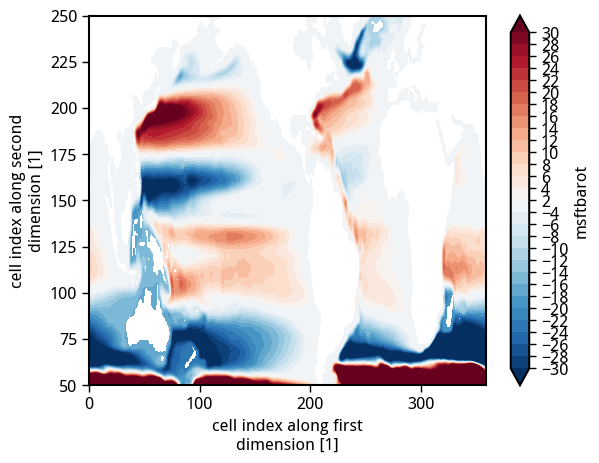

In [85]:
levels_min = np.arange(-30, -2, 2)
levels_max = np.arange(2, 32, 2)
levels = np.append(levels_min, levels_max)
# levels
(test.msftbarot.sel(time = slice('2000', '2010'), j=slice(50,250)).mean('time')/10**9).plot.contourf(levels=levels, extend='both', cbar_kwargs=dict(ticks=levels))

In [29]:
test.msftbarot

<xarray.DataArray 'msftbarot' (time: 1980, j: 300, i: 360)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
  * j          (j) int32 0 1 2 3 4 5 6 7 8 ... 292 293 294 295 296 297 298 299
  * i          (i) int32 0 1 2 3 4 5 6 7 8 ... 352 353 354 355 356 357 358 359
    latitude   (j, i) float64 -77.88 -77.88 -77.88 -77.88 ... 66.04 65.63 65.21
    longitude  (j, i) float64 81.0 82.0 83.0 84.0 85.0 ... 80.0 80.0 80.0 80.0
Attributes:
    standard_name:  ocean_barotropic_mass_streamfunction
    long_name:      Ocean Barotropic Mass Streamfunction
    comment:        Streamfunction or its approximation for free surface mode...
    units:          kg s-1
    cell_methods:   area: mean where sea time: mean
    cell_measures:  area: areacello
    history:        2020-06-05T05:00:53Z altered by CMOR: replaced missing va...

In [10]:
# obs_sst_anom_det = funcs.detrend_separate_check(obs_sst_anom, dim='time', period=30)

In [11]:
# obs_sst_anom_det

In [12]:
obs_trend = funcs.calc_trend3d(obs_sst_anom.sel(time = slice('1980', '2014')), 'time')
obs_pval = funcs.calc_trend_pval3d(obs_sst_anom.sel(time = slice('1980', '2014')), 'time')

In [13]:
# obs_trend_det = funcs.calc_trend3d(obs_sst_anom_det.sel(time = slice('1980', '2022')), 'time')
# obs_pval_det = funcs.calc_trend_pval3d(obs_sst_anom_det.sel(time = slice('1980', '2022')), 'time')

In [14]:
# obs_trend2 = funcs.calc_trend3d(obs_sst_anom.sel(time = slice('1920', '1960')), 'time')
# obs_pval2 = funcs.calc_trend_pval3d(obs_sst_anom.sel(time = slice('1920', '1960')), 'time')

In [15]:
xx, yy = np.meshgrid(obs_trend.lon, obs_trend.lat)

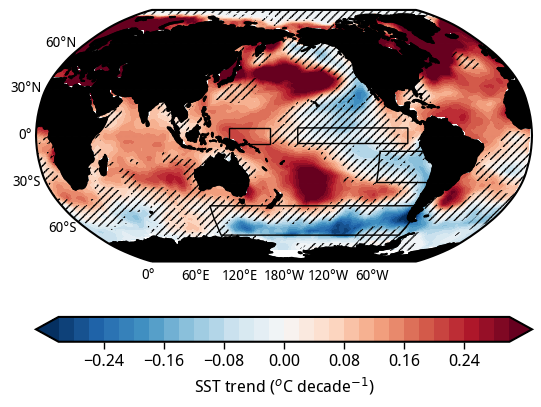

In [16]:
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
plot_background(ax)
ax.add_feature(cfeature.LAND, color='k', zorder=2)
zz = np.ma.masked_less_equal(obs_pval, 0.05)
obs_trend.plot.contourf(cmap='RdBu_r', levels=np.arange(-0.3, 0.32, 0.02), extend='both', transform=ccrs.PlateCarree(), cbar_kwargs=dict(orientation='horizontal', label='SST trend ($^{o}$C decade$^{-1}$)'))
ax.pcolor(xx, yy, zz, alpha=0., hatch='////', transform=ccrs.PlateCarree())
ax.add_patch(mpatches.Rectangle(xy=[120, -65], width=170, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[190, -5], width=80, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[140, -5], width=30, height=10,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))
ax.add_patch(mpatches.Rectangle(xy=[250, -30], width=40, height=20,
                                facecolor='none', edgecolor='k',
                                transform=ccrs.PlateCarree()))

plt.savefig('./images/obs.png', dpi=300, bbox_inches='tight')


In [11]:
weights = np.cos(np.deg2rad(obs_sst_anom.lat))

In [12]:
obs_nino34_index = funcs.detrend_separate_check(obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), dim='time', period=15)
# obs_nino3_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(-150+360, -90+360)).weighted(weights).mean(('lat', 'lon'))
# obs_nino4_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(160, -150+360)).weighted(weights).mean(('lat', 'lon'))
obs_wp_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
obs_ct_sst = obs_sst_anom.sel(lat = slice(5,-5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
obs_so_sst = obs_sst_anom.sel(lat = slice(-45, -65), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

In [13]:
obs_nino34_index.sel(time = slice('1980', '2014')).std()

<xarray.DataArray 'sst' ()>
array(0.76884083)

In [14]:
stats.skew(obs_nino34_index.sel(time = slice('1980', '2014')))

0.17415373403900805

In [10]:
from statsmodels.tsa.seasonal import STL


def loess1d(x, period):
    x_copy = x.copy()
    res = STL(x_copy, period=period).fit()
    return res.trend


def loess3d(x, dim, period):
    return xr.apply_ufunc(loess1d, x, input_core_dims=[[dim]], output_core_dims=[[dim]], kwargs=dict(period=period), vectorize=True, dask="parallelized")

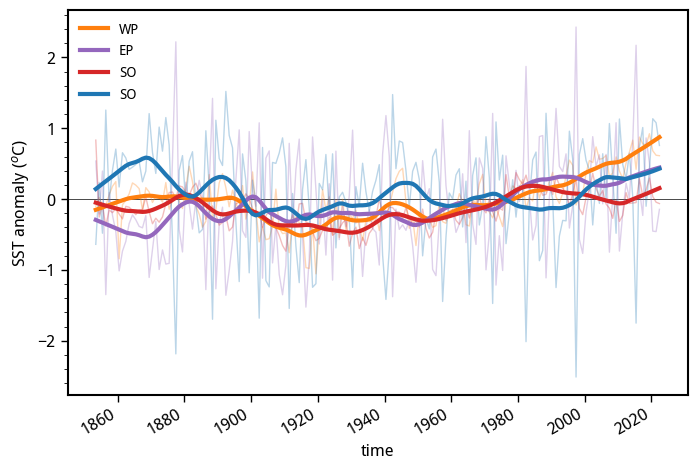

In [16]:
plt.figure(figsize=(8,5))
plt.axhline(0.0, color='k', lw=0.5)
(obs_wp_sst.sel(time = slice('1850', '2022'))).plot(color='tab:orange', lw=1.0, alpha=0.3)
(obs_ct_sst.sel(time = slice('1850', '2022'))).plot(color='tab:purple', lw=1.0, alpha=0.3)
(obs_so_sst.sel(time = slice('1850', '2022'))).plot(color='tab:red', lw=1.0, alpha=0.3)
(obs_wp_sst.sel(time = slice('1850', '2022')) - obs_ct_sst.sel(time = slice('1850', '2022'))).plot(color='tab:blue', lw=1.0, alpha=0.3)

loess3d(obs_wp_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:orange', lw=3.0, label='WP')
loess3d(obs_ct_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:purple', lw=3.0, label='EP')
loess3d(obs_so_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:red', lw = 3.0, label='SO')
loess3d(obs_wp_sst.sel(time = slice('1850', '2022')) - obs_ct_sst.sel(time = slice('1850', '2022')), dim='time', period=10).plot(color='tab:blue', lw = 3.0, label='SO')
plt.minorticks_on()
plt.gca().tick_params(axis='x', which='minor', bottom=False)
plt.ylabel('SST anomaly ($^{o}$C)')
plt.legend(frameon=False, fontsize=10)

In [11]:
import glob
import multiprocessing as mp

In [12]:
# Function to find the first file in each model's r1* directory
def find_all_files(pattern):
    all_paths = glob.glob(pattern)
    model_files = {}
    for path in all_paths:
        # Adjust the split indices based on your folder structure
        path_parts = path.split('/')
        # Assuming the model name is at index 7 (adjust if needed)
        model_identifier = path_parts[7]
        if model_identifier not in model_files:
            model_files[model_identifier] = path  # Store only the first file for each model
    return model_files


In [13]:
ts_pattern_hist = '/g/data/lp01/CMIP6/CMIP/*/*/historical/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_historical_*_gr1.5_185001-201412.nc'
ts_pattern_ssp5 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp585/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp585_*_gr1.5_201501-*.nc'
ts_pattern_ssp3 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp370/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp370_*_gr1.5_201501-*.nc'
ts_pattern_ssp2 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp245/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp245_*_gr1.5_201501-*.nc'
ts_pattern_ssp1 = '/g/data/lp01/CMIP6/ScenarioMIP/*/*/ssp126/r1i1*/Amon/ts/gr1.5/*/ts_Amon_*_ssp126_*_gr1.5_201501-*.nc'


In [14]:
ts_files_hist = find_all_files(ts_pattern_hist)
ts_files_ssp5 = find_all_files(ts_pattern_ssp5)
ts_files_ssp3 = find_all_files(ts_pattern_ssp3)
ts_files_ssp2 = find_all_files(ts_pattern_ssp2)
ts_files_ssp1 = find_all_files(ts_pattern_ssp1)

In [15]:
paths = ['/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp534-over/r1i1p1f1/Amon/ts/gn/v20210928/ts_Amon_ACCESS-CM2_ssp534-over_r1i1p1f1_gn_204101-210012.nc',
'/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp534-over/r1i1p1f1/Amon/ts/gn/v20211020/ts_Amon_ACCESS-ESM1-5_ssp534-over_r1i1p1f1_gn_204101-210012.nc',
'/g/data/oi10/replicas/CMIP6/ScenarioMIP/CAS/FGOALS-g3/ssp534-over/r1i1p1f1/Amon/ts/gn/v20200410/*.nc',
'/g/data/oi10/replicas/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp534-over/r1i1p1f1/Amon/ts/gn/v20190429/*.nc',
'/g/data/oi10/replicas/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp534-over/r1i1p1f1/Amon/ts/gr/v20190909/*.nc',
'/g/data/oi10/replicas/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp534-over/r1i1p1f1/Amon/ts/gn/v20190807/ts_Amon_MIROC6_ssp534-over_r1i1p1f1_gn_204001-210012.nc',
'/g/data/oi10/replicas/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp534-over/r1i1p1f1/Amon/ts/gn/v20191108/*.nc',]
model_names = ['ACCESS-CM2', 'ACCESS-ESM1-5', 'FGOALS-g3', 'CanESM5', 'IPSL-CM6A-LR', 'MIROC6', 'MRI-ESM2-0']
ts_files_ssp5_over = dict(zip(model_names, paths))
ts_files_ssp5_over

{'ACCESS-CM2': '/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO-ARCCSS/ACCESS-CM2/ssp534-over/r1i1p1f1/Amon/ts/gn/v20210928/ts_Amon_ACCESS-CM2_ssp534-over_r1i1p1f1_gn_204101-210012.nc',
 'ACCESS-ESM1-5': '/g/data/fs38/publications/CMIP6/ScenarioMIP/CSIRO/ACCESS-ESM1-5/ssp534-over/r1i1p1f1/Amon/ts/gn/v20211020/ts_Amon_ACCESS-ESM1-5_ssp534-over_r1i1p1f1_gn_204101-210012.nc',
 'FGOALS-g3': '/g/data/oi10/replicas/CMIP6/ScenarioMIP/CAS/FGOALS-g3/ssp534-over/r1i1p1f1/Amon/ts/gn/v20200410/*.nc',
 'CanESM5': '/g/data/oi10/replicas/CMIP6/ScenarioMIP/CCCma/CanESM5/ssp534-over/r1i1p1f1/Amon/ts/gn/v20190429/*.nc',
 'IPSL-CM6A-LR': '/g/data/oi10/replicas/CMIP6/ScenarioMIP/IPSL/IPSL-CM6A-LR/ssp534-over/r1i1p1f1/Amon/ts/gr/v20190909/*.nc',
 'MIROC6': '/g/data/oi10/replicas/CMIP6/ScenarioMIP/MIROC/MIROC6/ssp534-over/r1i1p1f1/Amon/ts/gn/v20190807/ts_Amon_MIROC6_ssp534-over_r1i1p1f1_gn_204001-210012.nc',
 'MRI-ESM2-0': '/g/data/oi10/replicas/CMIP6/ScenarioMIP/MRI/MRI-ESM2-0/ssp534-over/r1i1p1f1/Amon/t

In [16]:
# ts_pattern_access_hist = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst/'
# ts_pattern_access_ssp = '/g/data/ob22/as8561/data/enso_trans_stable/hist_ssp_runs/regrid_sst'

In [17]:
import xesmf as xe

In [18]:
temp_hist = xr.open_dataset(ts_files_hist['ACCESS-CM2'])
temp_hist

<xarray.Dataset>
Dimensions:    (time: 1980, bnds: 2, lon: 240, lat: 120)
Coordinates:
  * time       (time) datetime64[ns] 1850-01-16T12:00:00 ... 2014-12-16T12:00:00
  * lon        (lon) float64 0.0 1.5 3.0 4.5 6.0 ... 354.0 355.5 357.0 358.5
  * lat        (lat) float64 -89.25 -87.75 -86.25 -84.75 ... 86.25 87.75 89.25
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] ...
    ts         (time, lat, lon) float32 ...
Attributes: (12/50)
    CDI:                       Climate Data Interface version 1.9.8 (https://...
    history:                   Mon May 24 10:59:48 2021: cdo -O -L -P 28 -rem...
    source:                    ACCESS-CM2 (2019): \naerosol: UKCA-GLOMAP-mode...
    institution:               CSIRO (Commonwealth Scientific and Industrial ...
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    version:                   v20191108
    cmor_version:              3.4.0
    tracking_id:               hdl:21.14100/246cb7d2-3eb7-4127-a23f-35467313072f
    license:                   CMIP6 model data produced by CSIRO is licensed...
    CDO:                       Climate Data Operators version 1.9.8 (https://...
    cdo_openmp_thread_number:  28

In [19]:
ds_out = xe.util.cf_grid_2d(-0.75, 360, 1.5, -90, 90, 1.5)
ds_out

<xarray.Dataset>
Dimensions:             (lon: 240, bound: 2, lat: 120)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
Dimensions without coordinates: bound
Data variables:
    lon_bounds          (lon, bound) float64 -0.75 0.75 0.75 ... 357.8 359.2
    lat_bounds          (lat, bound) float64 -90.0 -88.5 -88.5 ... 88.5 90.0

In [20]:
# Function to process a single model and return the detrended NINO3.4 and precip anomalies
def process_model(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        ts_file_hist = ts_files_hist[model_identifier]
        ts_file_ssp = ts_files_ssp3[model_identifier]
        ds_sst_hist = xr.open_dataset(ts_file_hist)
        ds_sst_ssp = xr.open_dataset(ts_file_ssp)
        # add custom time ranges
        ds_sst_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_end_year = int(ds_sst_ssp.time.dt.year[-1])
        ds_sst_ssp['time'] = xr.cftime_range('2015-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        #
        ts = xr.concat([ds_sst_hist, ds_sst_ssp], dim='time').ts.resample(time = 'AS-JUN').mean('time').load()  # SST data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        ts_anom = funcs.calc_anom_annual(ts, ts.sel(time = slice('1960', '1990')))
        ts_trend = funcs.calc_trend3d(ts_anom.sel(time = slice('1980', '2014')), 'time')
        ts_trend_pval = funcs.calc_trend_pval3d(ts_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        weights = np.cos(np.deg2rad(ts.lat))
        gmst_anom = ts_anom.weighted(weights).mean(('lat', 'lon'))
        nino34_index = funcs.detrend1d_check(ts_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        wp_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        ct_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        so_sst = ts_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, ts_trend, ts_trend_pval, gmst_anom, nino34_index, wp_sst, ct_sst, so_sst
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        # break



# Function to process a single model and return the detrended NINO3.4 and precip anomalies
# TODO : remapping required for ssp534_over
def process_model_overshoot(model_identifier):
    try:
        # print(f"Processing model: {model_identifier}")
        # Load datasets
        ts_file_hist = ts_files_hist[model_identifier]
        ts_file_ssp5_over = ts_files_ssp5_over[model_identifier]
        ts_file_ssp5 = ts_files_ssp5[model_identifier]
        ds_sst_hist = xr.open_dataset(ts_file_hist)
        ds_sst_ssp5_over = xr.open_mfdataset(ts_file_ssp5_over, use_cftime=True).load()
        regridder = xe.Regridder(ds_sst_ssp5_over, ds_out, 'bilinear', periodic=True)
        ds_sst_ssp5_over_regr = regridder(ds_sst_ssp5_over)
        ds_sst_ssp5 = xr.open_dataset(ts_file_ssp5)
        # add custom time ranges
        ds_sst_hist['time'] = xr.cftime_range('1850-01-01', '2015-01-01', freq='1M')
        ssp_start_year = int(ds_sst_ssp5_over_regr.time.dt.year[0])
        ssp_end_year = int(ds_sst_ssp5_over_regr.time.dt.year[-1])
        ds_sst_ssp5 = ds_sst_ssp5.sel(time = slice(str(2015), str(ssp_start_year-1)))
        ds_sst_ssp5['time'] = xr.cftime_range('2015-01-01', f'{ssp_start_year}-01-01', freq='1M')
        ds_sst_ssp5_over_regr['time'] = xr.cftime_range(f'{ssp_start_year}-01-01', f'{ssp_end_year + 1}-01-01', freq='1M')
        
        ts = xr.concat([ds_sst_hist, ds_sst_ssp5, ds_sst_ssp5_over_regr], dim='time').ts.resample(time = 'AS-JUN').mean('time').load()  # SST data
        # precip = ds_precip['pr'] * 86400  # Convert kg/m²/s to mm/day

        # Calculate 3d values
        ts_anom = funcs.calc_anom_annual(ts, ts.sel(time = slice('1960', '1990')))
        ts_trend = funcs.calc_trend3d(ts_anom.sel(time = slice('1980', '2014')), 'time')
        ts_trend_pval = funcs.calc_trend_pval3d(ts_anom.sel(time = slice('1980', '2014')), 'time')

        # calc timeseries values
        weights = np.cos(np.deg2rad(ts.lat))
        gmst_anom = ts_anom.weighted(weights).mean(('lat', 'lon'))
        nino34_index = funcs.detrend1d_check(ts_anom.sel(lat = slice(-5,5), lon = slice(-170+360, -120+360)).weighted(weights).mean(('lat', 'lon')), period=15)
        wp_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(140, 170)).weighted(weights).mean(('lat', 'lon'))
        ct_sst = ts_anom.sel(lat = slice(-5,5), lon = slice(190, 270)).weighted(weights).mean(('lat', 'lon'))
        so_sst = ts_anom.sel(lat = slice(-65, -45), lon = slice(120, 290)).weighted(weights).mean(('lat', 'lon'))

        # print(f'Completed: {model_identifie}')
        return model_identifier, ts_trend, ts_trend_pval, gmst_anom, nino34_index, wp_sst, ct_sst, so_sst
    except Exception as e:
        print(f"Error processing {model_identifier}: {e}")
        # break



In [21]:
models_to_process = [(model) for model in ts_files_hist if model in ts_files_ssp5_over and model != 'IPSL-CM5A2-INCA']
len(models_to_process), models_to_process

(6,
 ['CanESM5',
  'MIROC6',
  'IPSL-CM6A-LR',
  'ACCESS-CM2',
  'MRI-ESM2-0',
  'ACCESS-ESM1-5'])

In [22]:
# Run multiprocessing and gather results
res_arr = []
with mp.Pool(processes=mp.cpu_count()) as pool:
    i = 0
    for res in pool.imap(process_model_overshoot, models_to_process):
        res_arr.append(res)
        print(f'Completed {i+1}/{len(models_to_process)}', end='\r')
        i += 1



In [20]:
# models = np.array(res_arr)[:, 0]
# trend = np.array(res_arr)[:, 1]
# trend_pval = np.array(res_arr)[:, 2]
# nino34_index = np.array(res_arr)[:, 3]
# wp_sst = np.array(res_arr)[:, 4]
# cp_sst = np.array(res_arr)[:, 5]
# so_sst = np.array(res_arr)[:, 6]

In [23]:
def process_extensions(arr, get_extensions=True):
    if get_extensions:
        return [da for da in arr if len(da.time) == 452]
    else:
        return [da.sel(time = slice('1850-01-01', '2099-12-01')) for da in arr]

In [24]:
model_list = np.array(res_arr)[:, 0]

In [25]:
np.array(res_arr).shape

(6, 8)

In [26]:
model_list

array(['CanESM5', 'MIROC6', 'IPSL-CM6A-LR', 'ACCESS-CM2', 'MRI-ESM2-0',
       'ACCESS-ESM1-5'], dtype=object)

In [27]:
test = np.array(res_arr)[:, 4]
model_extensions = []
for i in range(len(test)):
    da = test[i]
    # print(len(da.time))
    if len(da.time) == 452:
        model_extensions.append(model_list[i])



model_extensions

['CanESM5', 'IPSL-CM6A-LR', 'MRI-ESM2-0']

In [28]:
len(process_extensions(np.array(res_arr)[:, 4], get_extensions=False))

6

In [29]:
model_trend = xr.concat(np.array(res_arr)[:, 1], dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'trend')
model_pval = xr.concat(np.array(res_arr)[:, 2], dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'pval')


In [30]:
model_gmst_anom = xr.concat(process_extensions(np.array(res_arr)[:, 3], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
model_nino34_index = xr.concat(process_extensions(np.array(res_arr)[:, 4], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
model_wp_sst = xr.concat(process_extensions(np.array(res_arr)[:, 5], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
model_ep_sst = xr.concat(process_extensions(np.array(res_arr)[:, 6], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
model_so_sst = xr.concat(process_extensions(np.array(res_arr)[:, 7], get_extensions=False), dim=model_list).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [31]:
out = xr.merge([model_trend, model_pval, model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])
out

<xarray.Dataset>
Dimensions:             (lon: 240, lat: 120, model: 6, time: 250)
Coordinates:
  * lon                 (lon) float64 0.0 1.5 3.0 4.5 ... 355.5 357.0 358.5
  * lat                 (lat) float64 -89.25 -87.75 -86.25 ... 86.25 87.75 89.25
    latitude_longitude  float64 nan
  * model               (model) object 'CanESM5' 'MIROC6' ... 'ACCESS-ESM1-5'
  * time                (time) object 1850-06-01 00:00:00 ... 2099-06-01 00:0...
Data variables:
    trend               (model, lat, lon) float64 0.3903 0.3977 ... 1.288 1.292
    pval                (model, lat, lon) float64 0.003766 0.004122 ... nan nan
    gmst_anom           (model, time) float64 -0.3548 -0.3768 ... 2.291 2.229
    nino34_index        (model, time) float64 -0.5888 0.1675 ... 0.2432 -0.3173
    wp_sst              (model, time) float64 -0.8709 -0.4416 ... 2.27 2.33
    ep_sst              (model, time) float64 -1.127 -0.3625 ... 2.616 1.956
    so_sst              (model, time) float64 -0.2105 -0.2664 ... 1.184 1.087

In [32]:
model_gmst_anom = xr.concat(process_extensions(np.array(res_arr)[:, 3], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'gmst_anom')
model_nino34_index = xr.concat(process_extensions(np.array(res_arr)[:, 4], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'nino34_index')
model_wp_sst = xr.concat(process_extensions(np.array(res_arr)[:, 5], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'wp_sst')
model_ep_sst = xr.concat(process_extensions(np.array(res_arr)[:, 6], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'ep_sst')
model_so_sst = xr.concat(process_extensions(np.array(res_arr)[:, 7], get_extensions=True), dim=model_extensions).rename(dict(concat_dim = 'model')).to_dataset(name = 'so_sst')

In [33]:
out_extensions = xr.merge([model_gmst_anom, model_nino34_index, model_wp_sst, model_ep_sst, model_so_sst])
out_extensions

<xarray.Dataset>
Dimensions:             (time: 452, model: 3)
Coordinates:
    latitude_longitude  float64 nan
  * time                (time) object 1849-06-01 00:00:00 ... 2300-06-01 00:0...
  * model               (model) object 'CanESM5' 'IPSL-CM6A-LR' 'MRI-ESM2-0'
Data variables:
    gmst_anom           (model, time) float64 -1.214 -0.3548 ... 1.174 1.797
    nino34_index        (model, time) float64 0.1838 -0.5888 ... -1.644 0.1276
    wp_sst              (model, time) float64 -0.9653 -0.8709 ... 0.645 0.9686
    ep_sst              (model, time) float64 -0.07254 -1.127 ... -0.1345 1.394
    so_sst              (model, time) float64 0.8282 -0.2105 ... 1.893 1.28

In [34]:
def find_model_agreement1d(arr):
    agree = 0
    for val in arr:
        if val < 0.05:
            agree += 1
    return agree/len(arr)

def find_model_agreement3d(da, dim):
    return xr.apply_ufunc(find_model_agreement1d, da, input_core_dims=[[dim]], vectorize=True, dask='parallelized')

In [35]:
out['pval_agreement'] = find_model_agreement3d(out.pval, dim='model')
# out_extensions['pval_agreement'] = find_model_agreement3d(out_extensions.pval, dim='model')

In [36]:
out.to_netcdf('./data/res/out_ssp5_over.nc')
out_extensions.to_netcdf('./data/res/out_ssp5_over_extensions.nc')